In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
random.seed(1)

### Data Analysis

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/mtcars.csv", index_col=0)
X = df.drop(['carb'], axis=1)
y = df[['carb']]

X.iloc[0, 0]

21.0

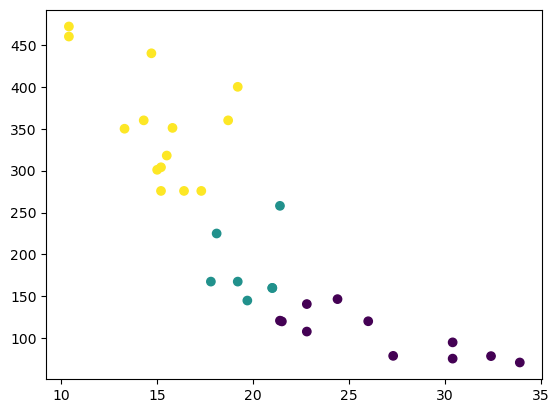

In [4]:
plt.scatter(df.iloc[:, 0], df.iloc[:, 2], c=df.iloc[:, 1])

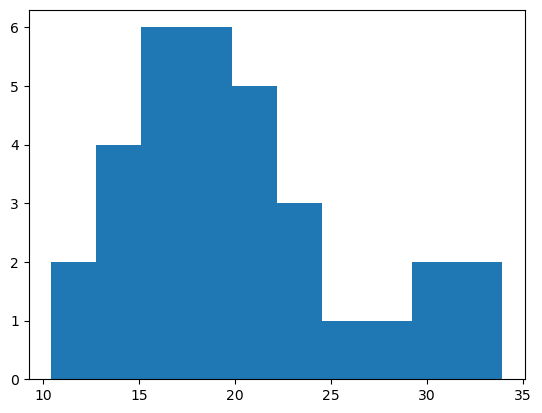

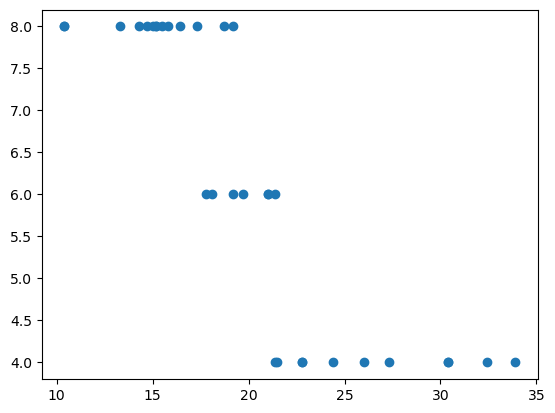

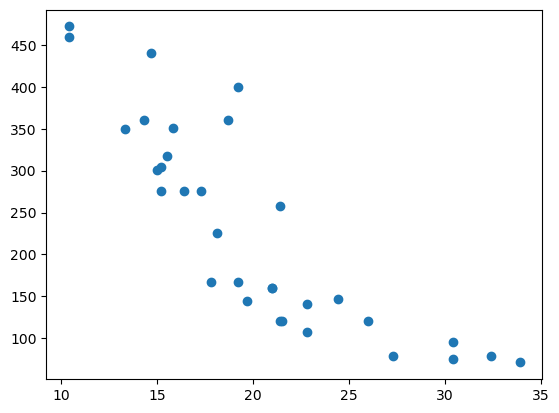

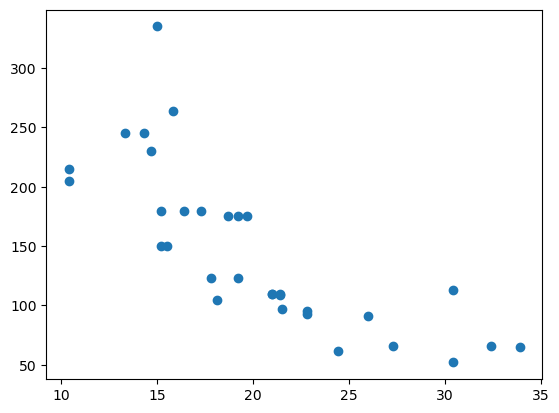

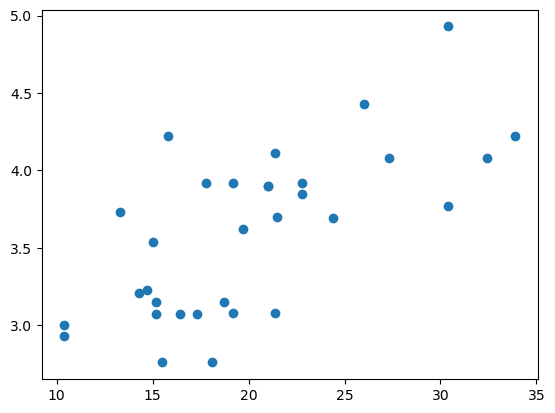

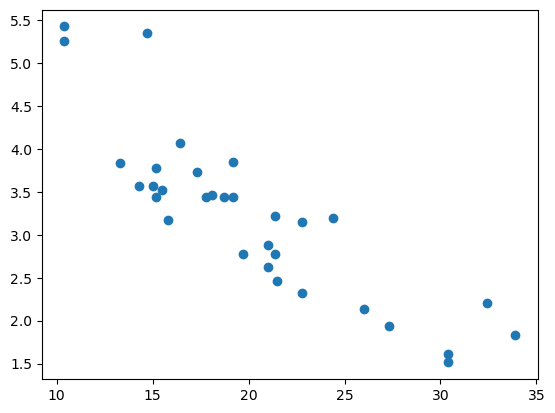

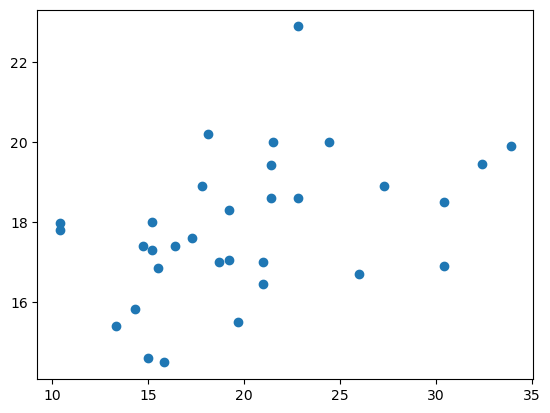

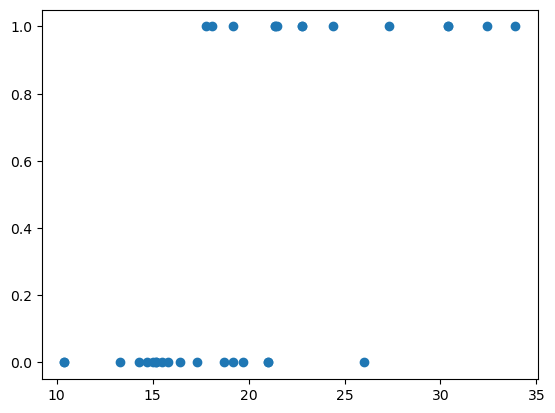

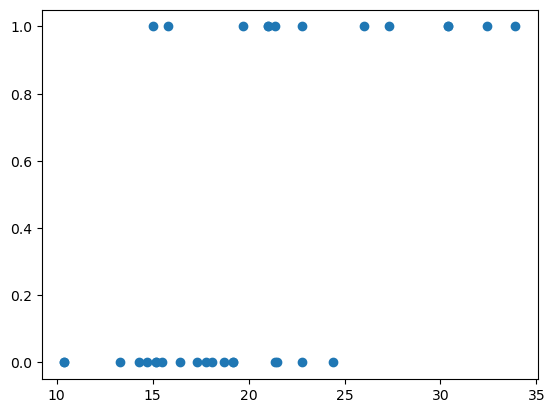

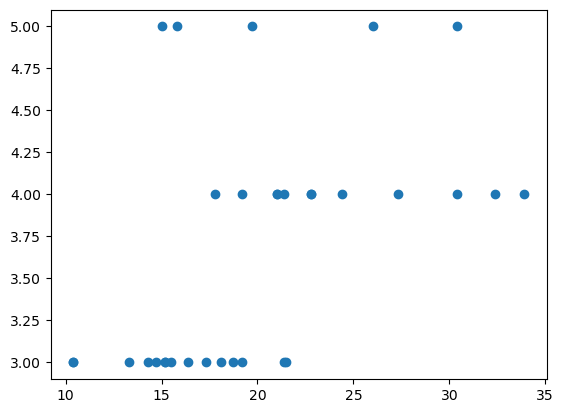

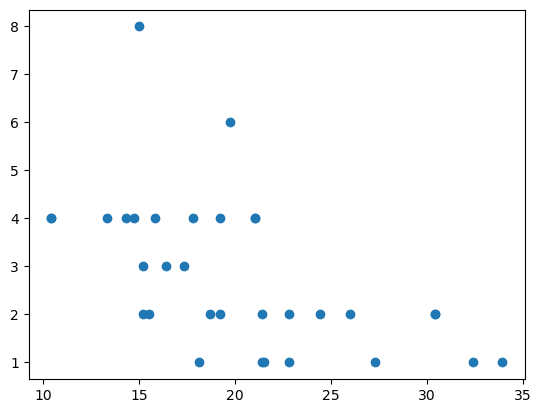

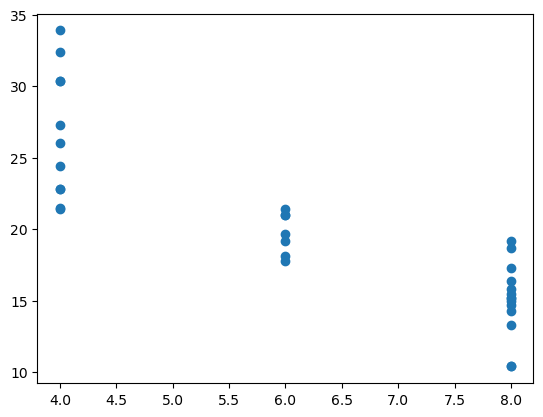

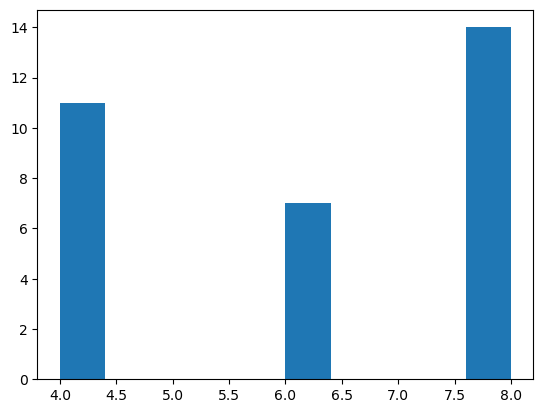

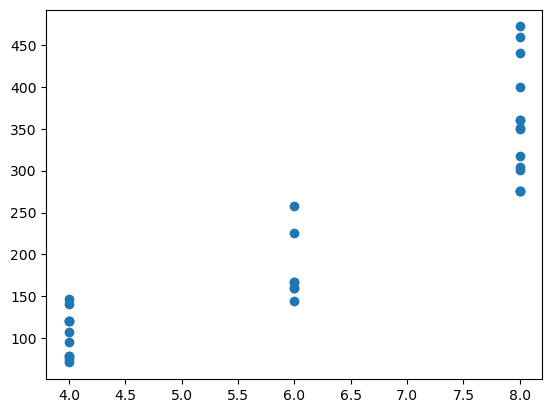

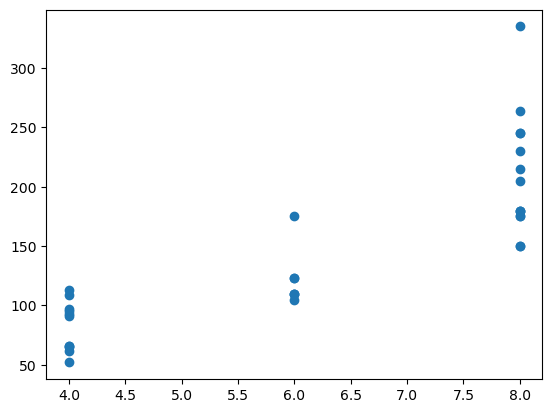

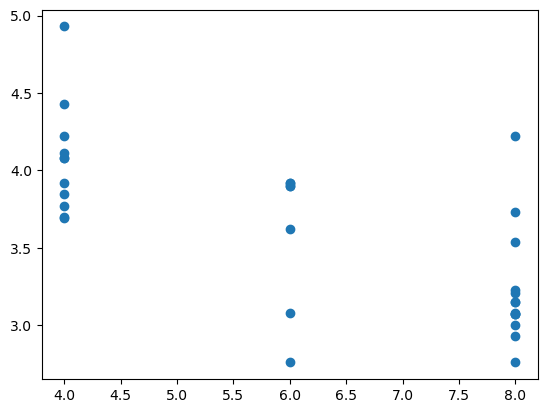

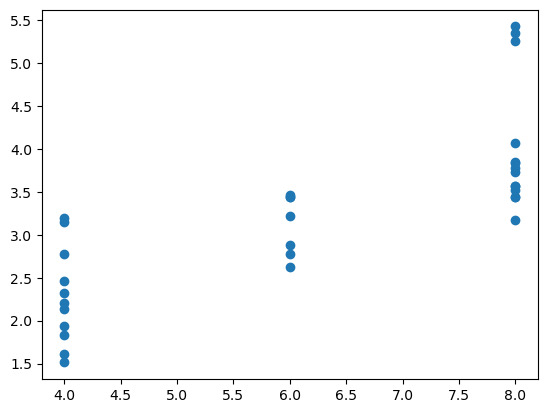

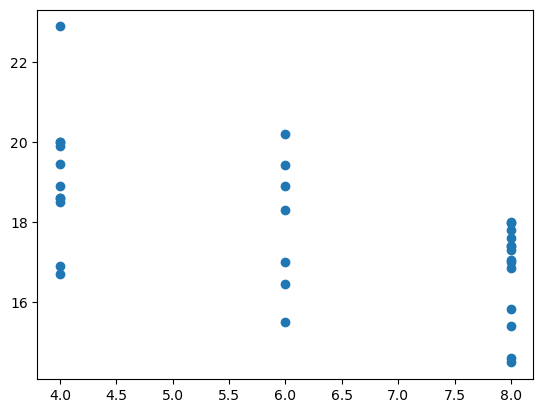

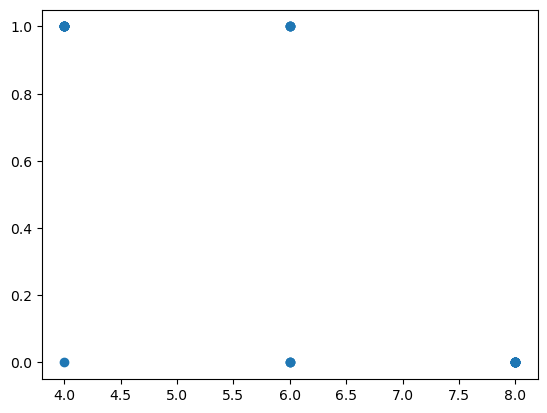

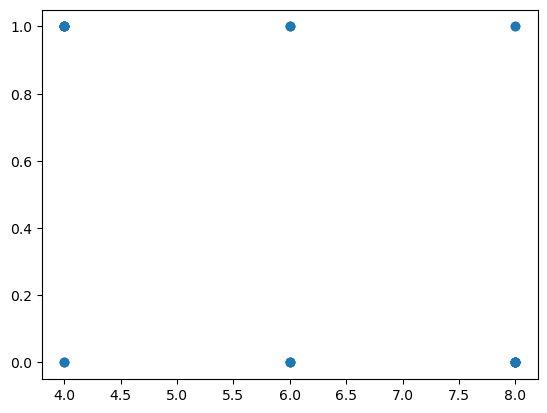

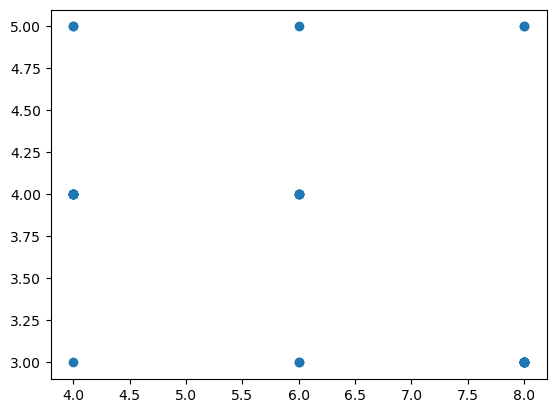

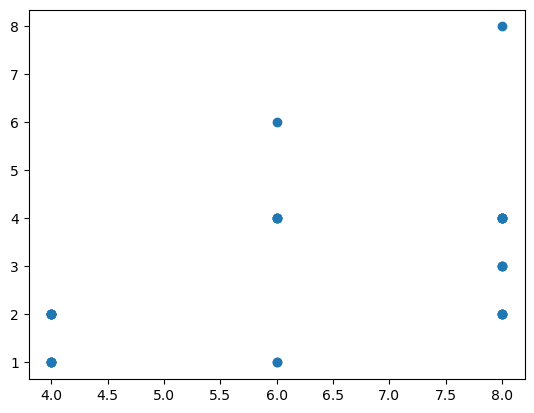

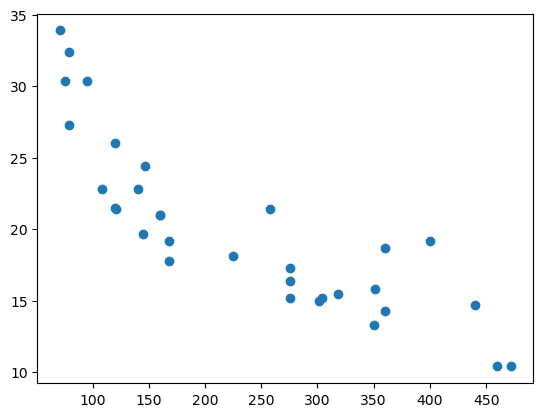

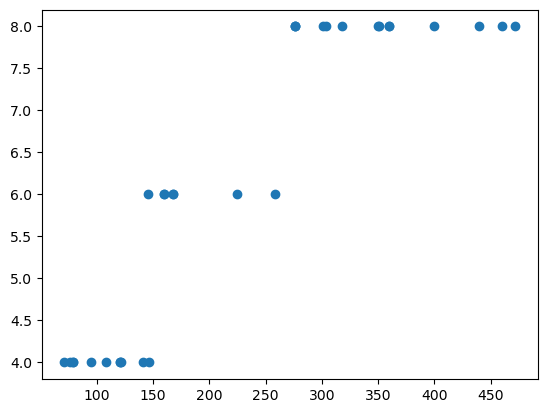

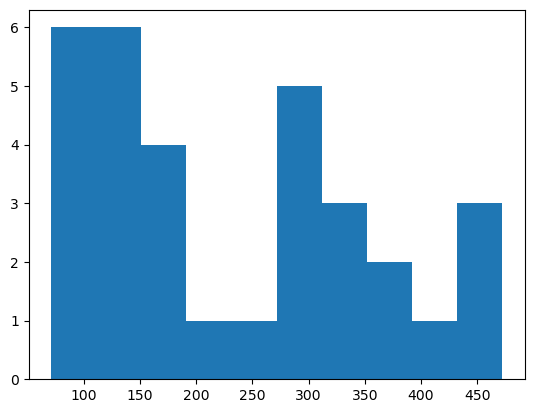

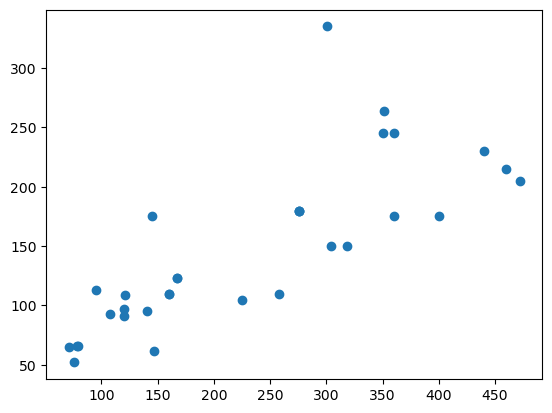

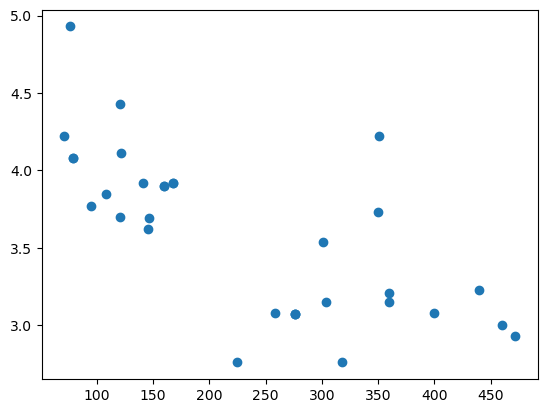

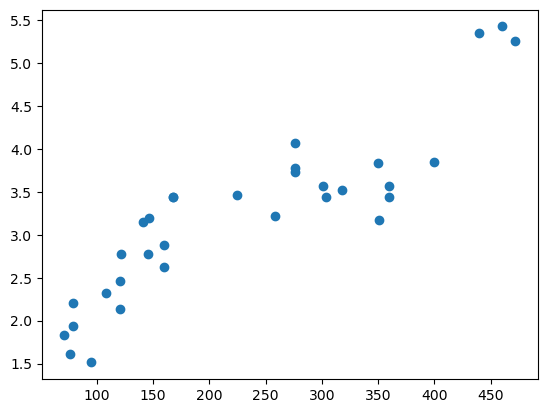

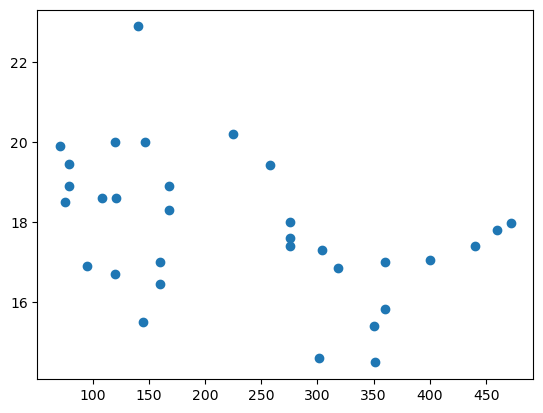

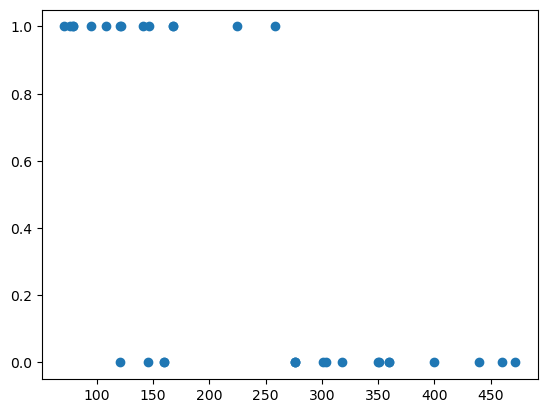

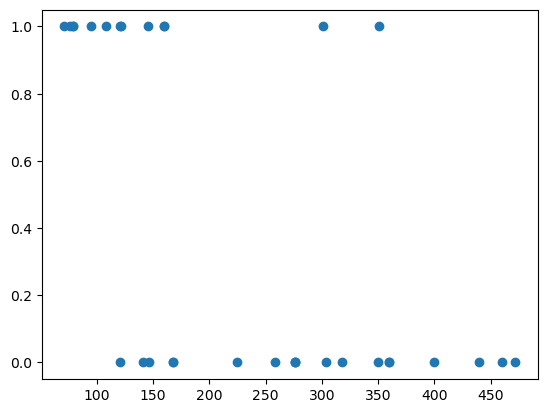

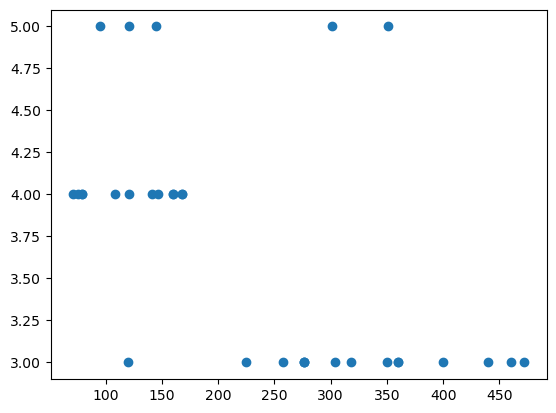

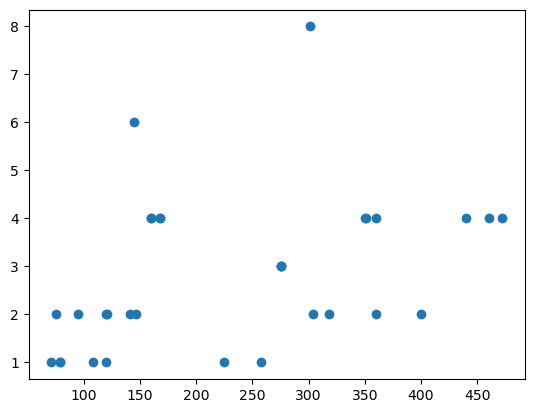

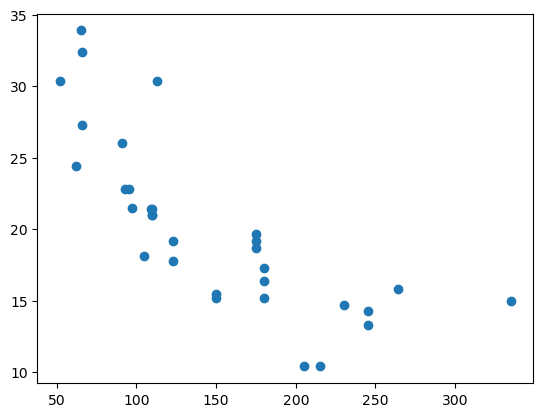

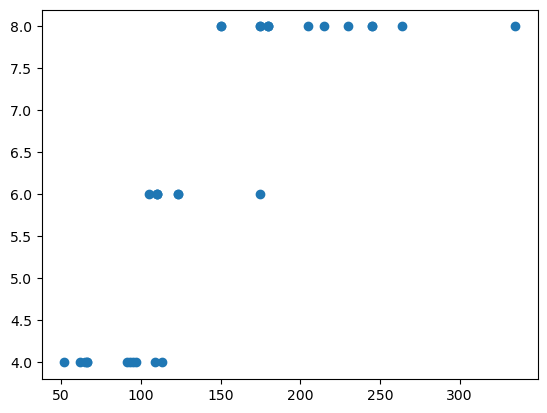

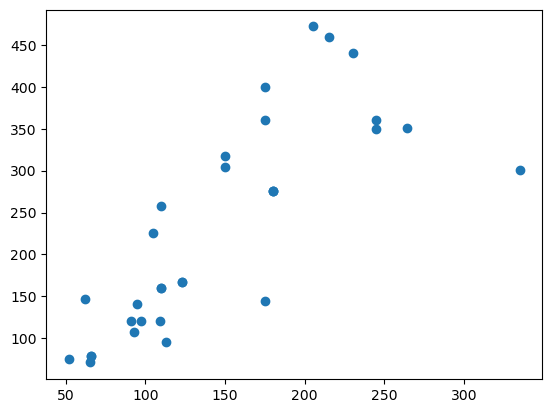

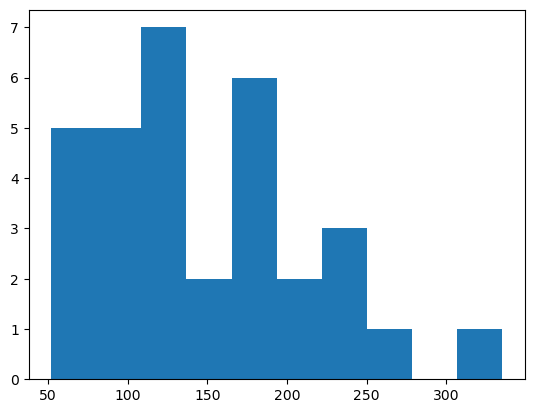

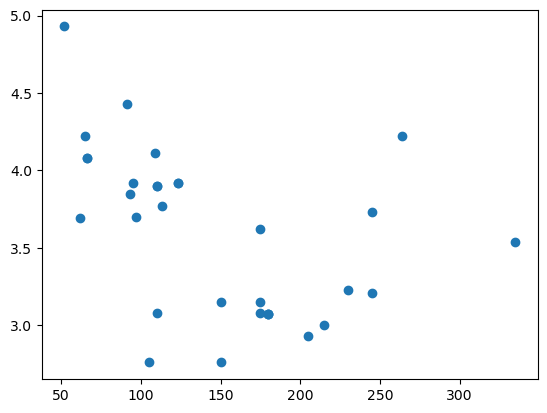

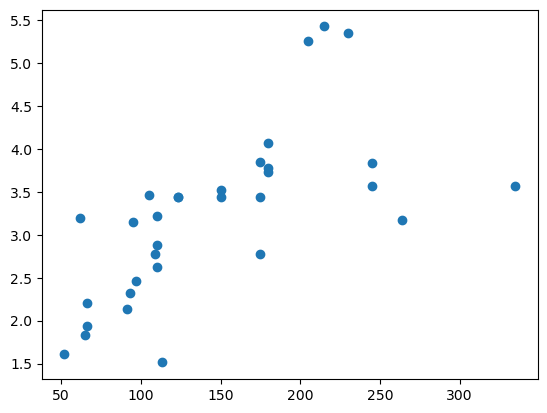

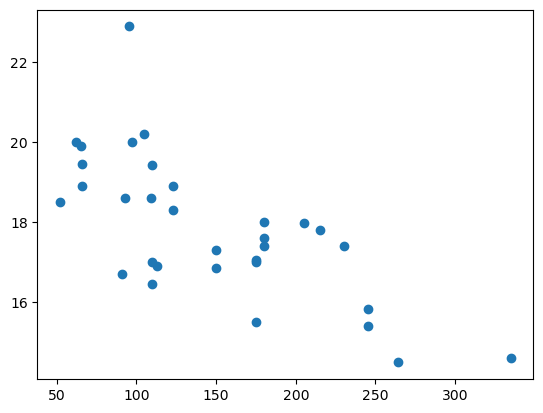

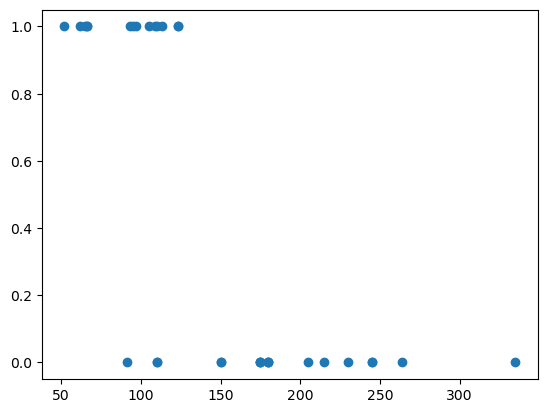

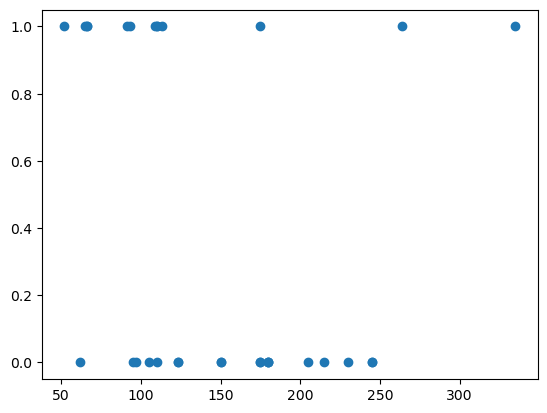

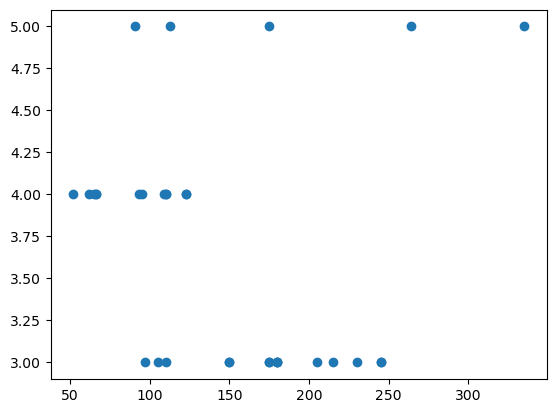

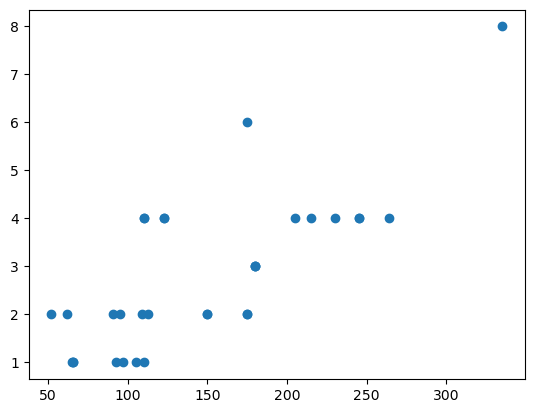

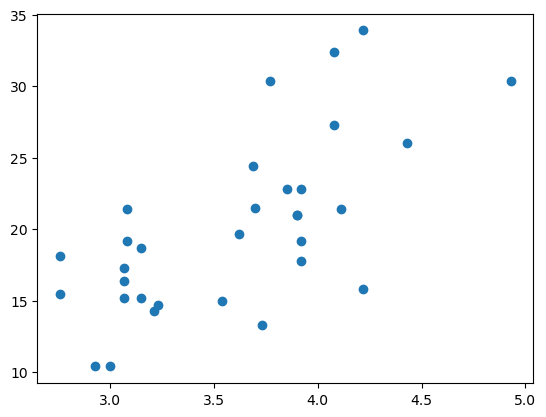

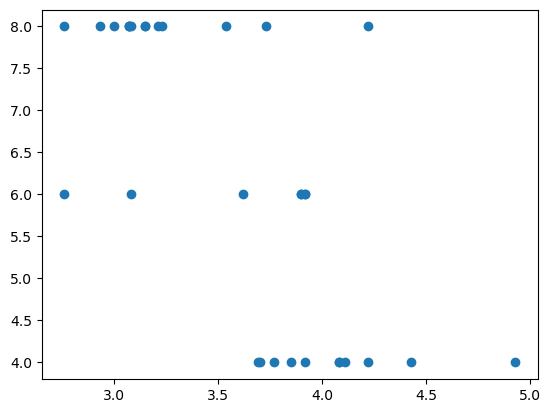

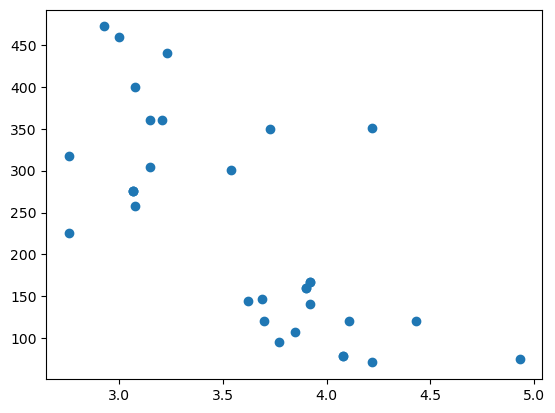

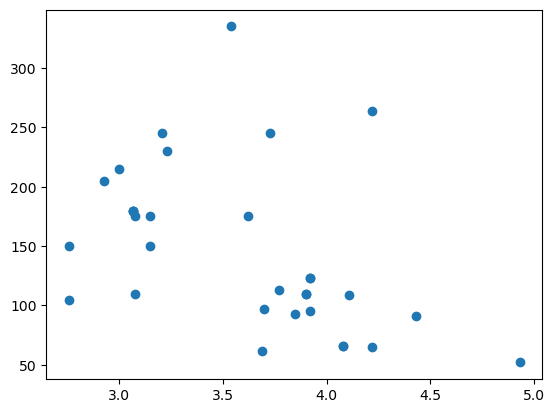

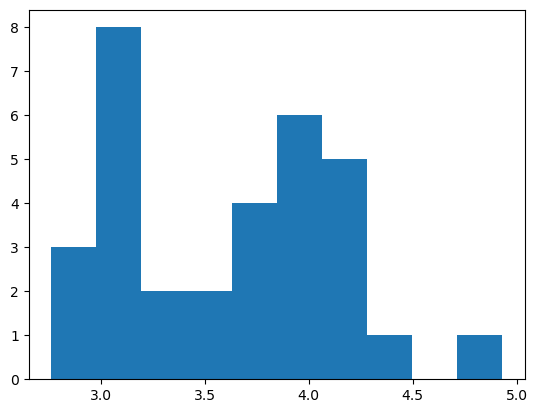

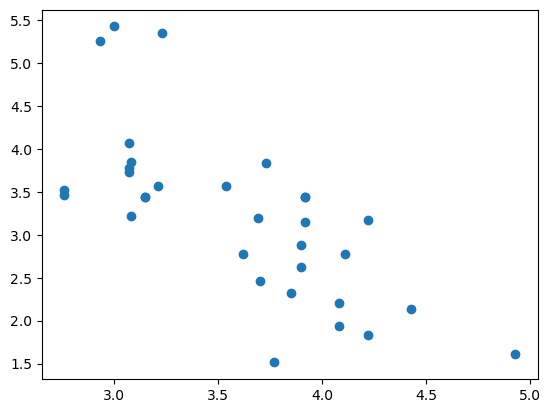

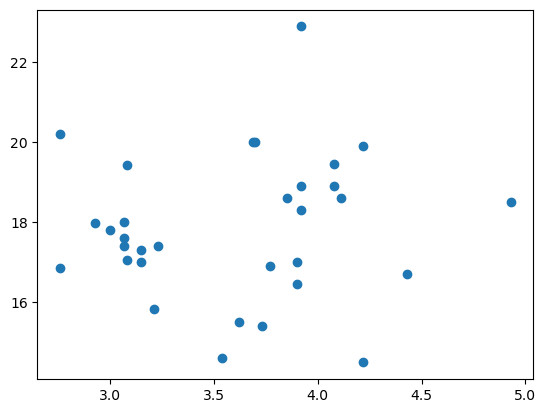

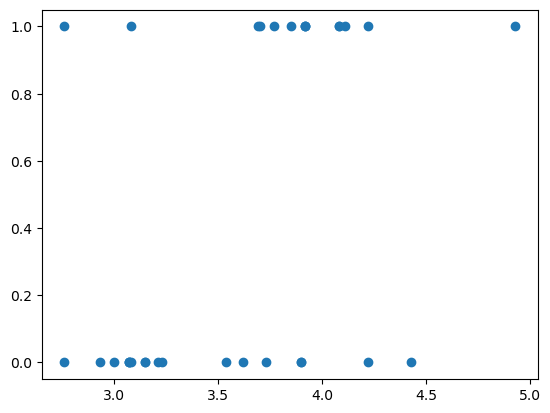

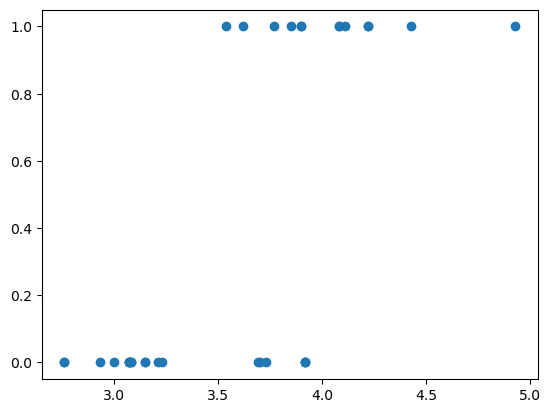

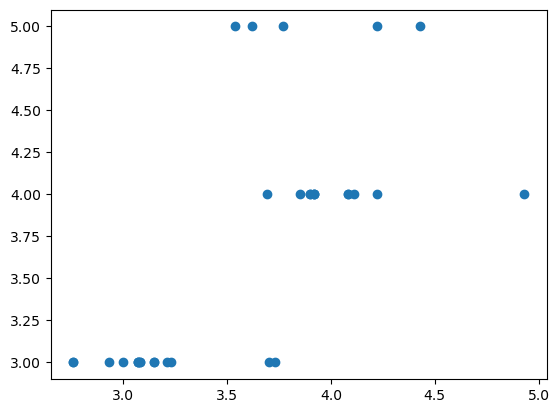

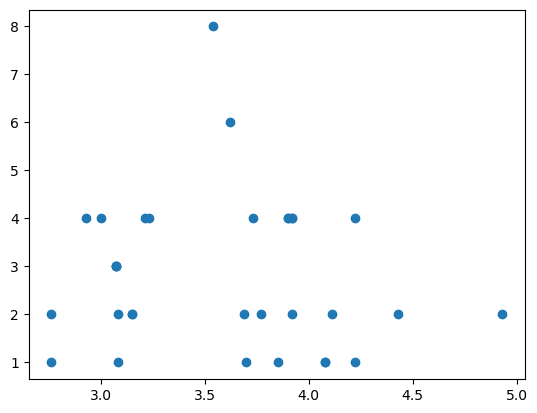

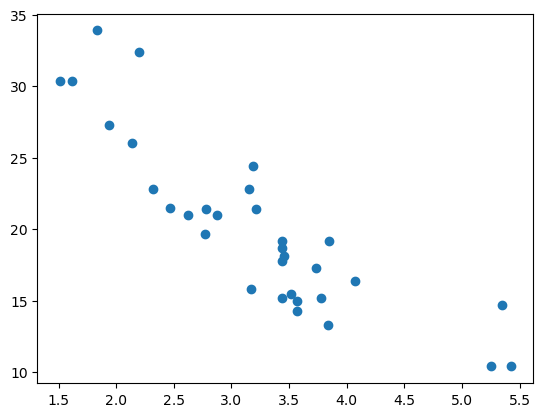

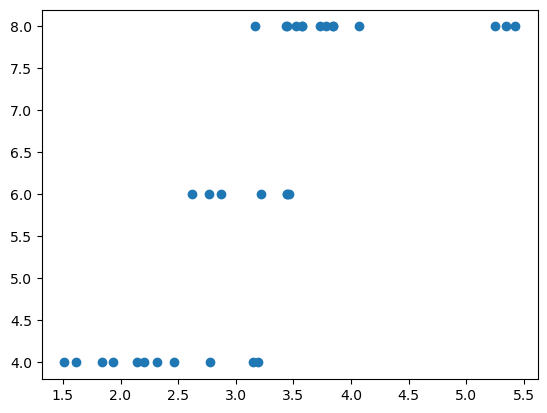

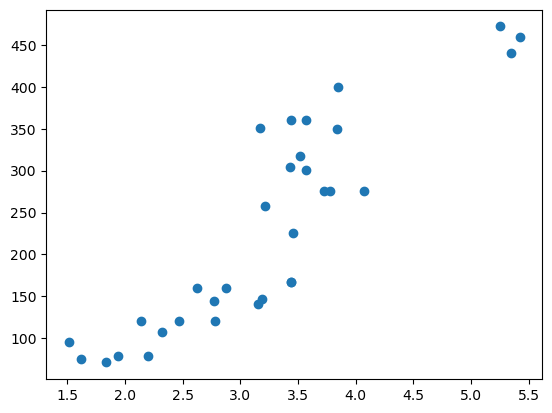

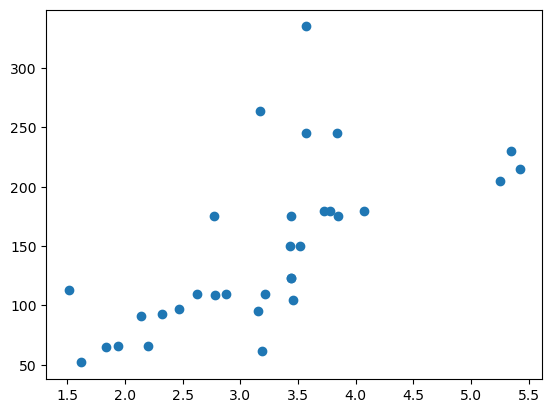

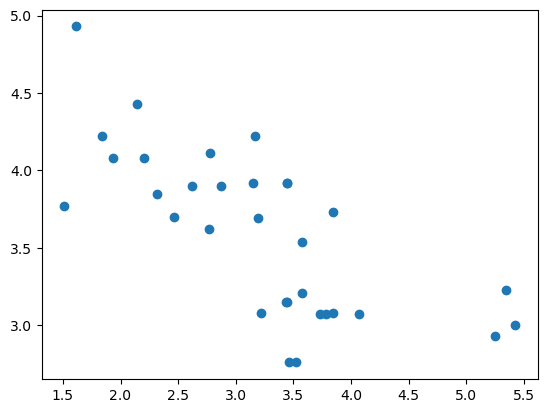

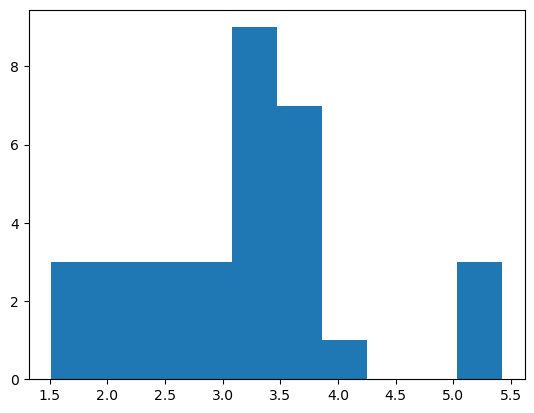

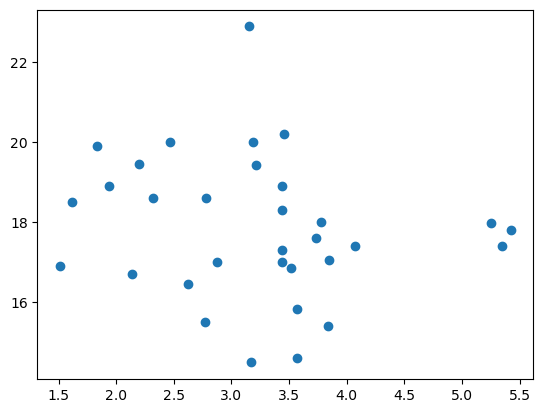

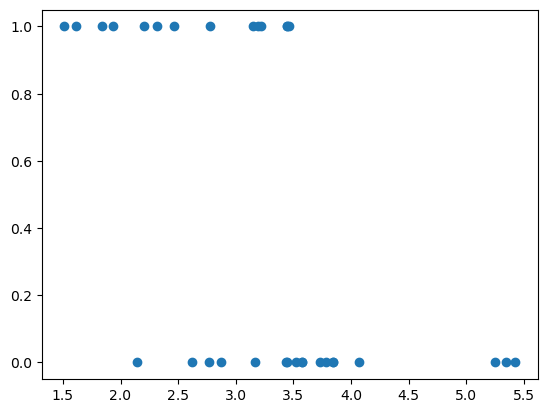

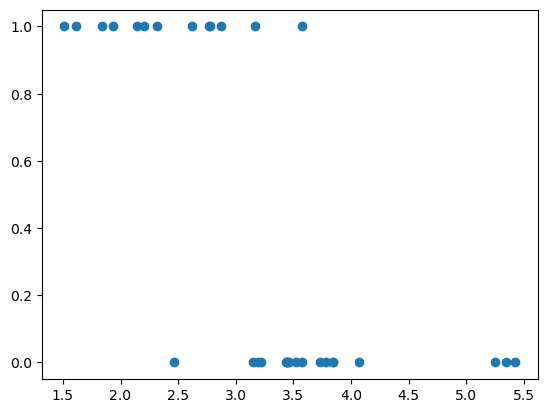

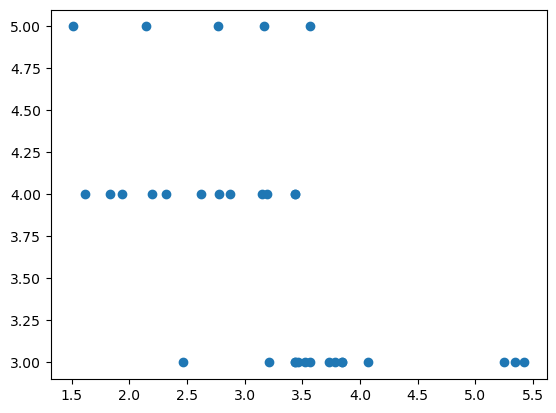

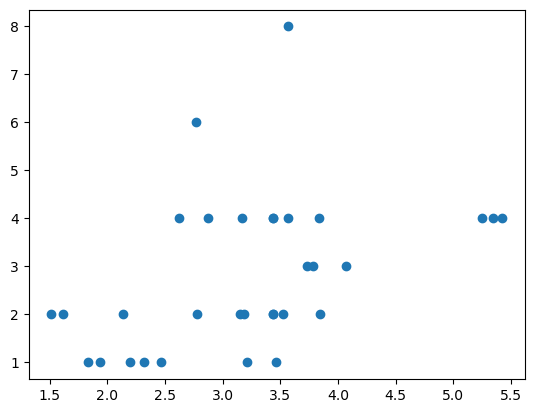

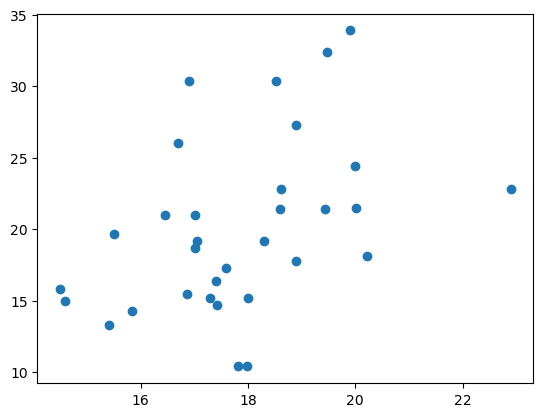

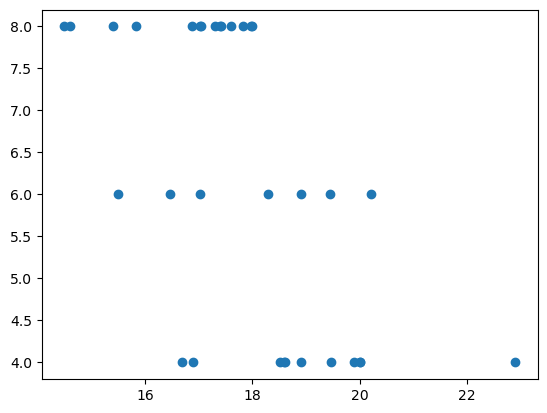

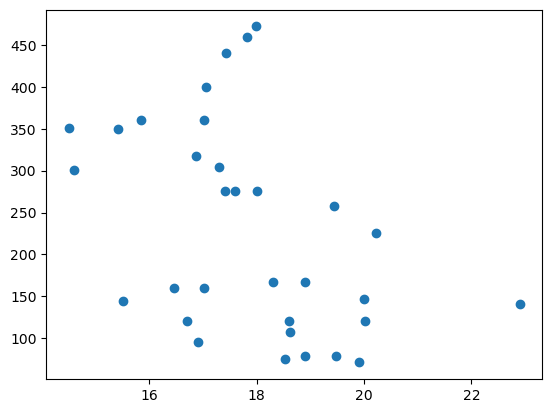

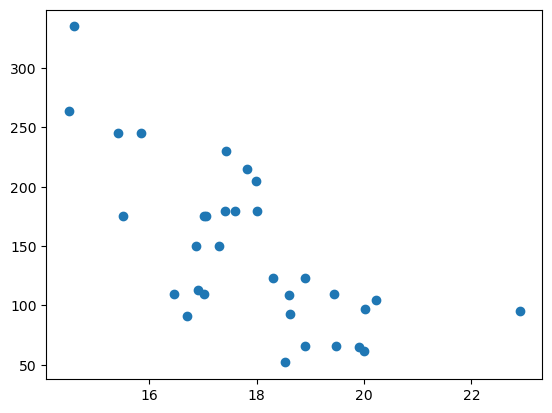

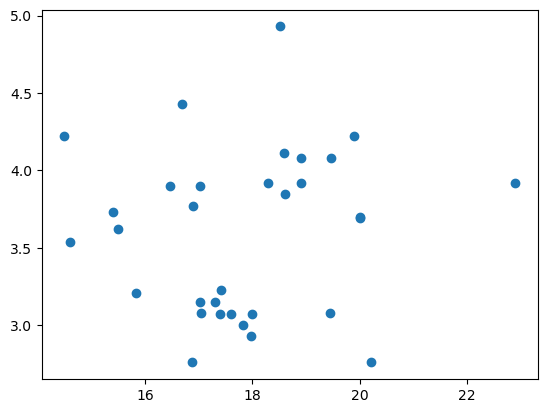

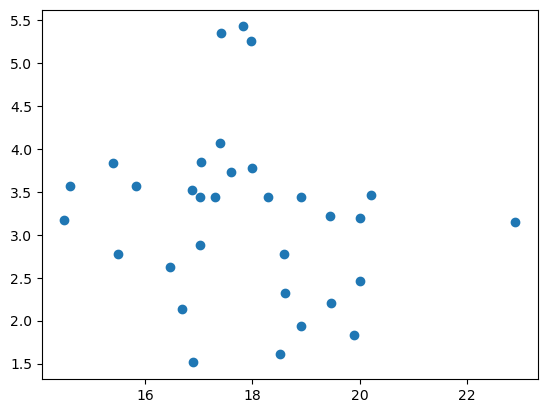

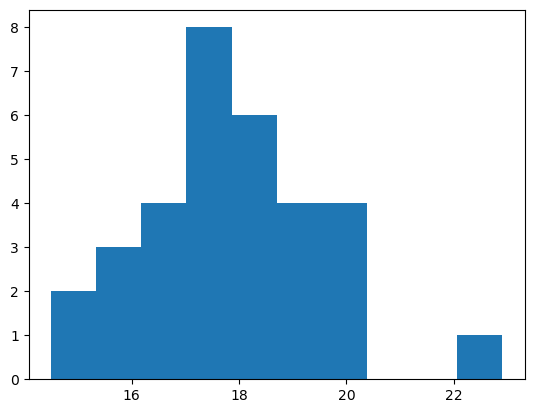

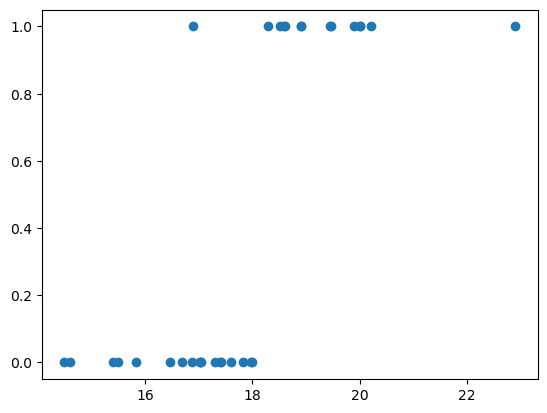

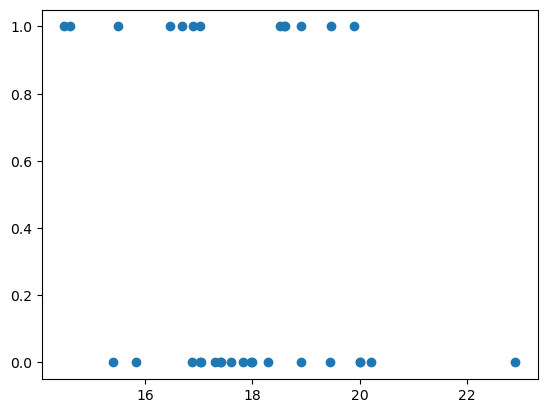

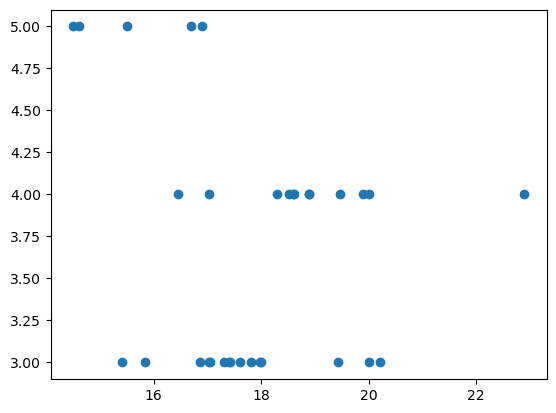

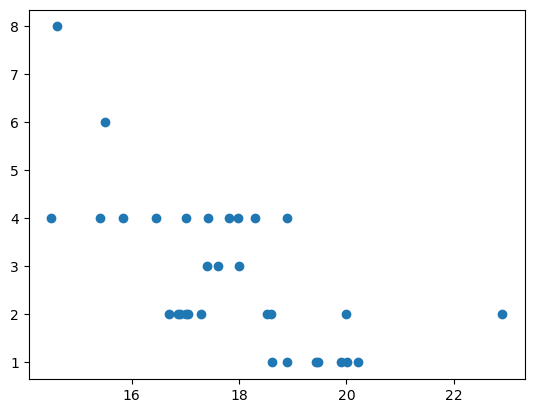

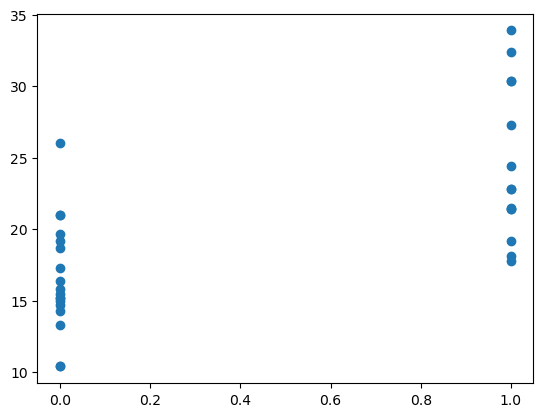

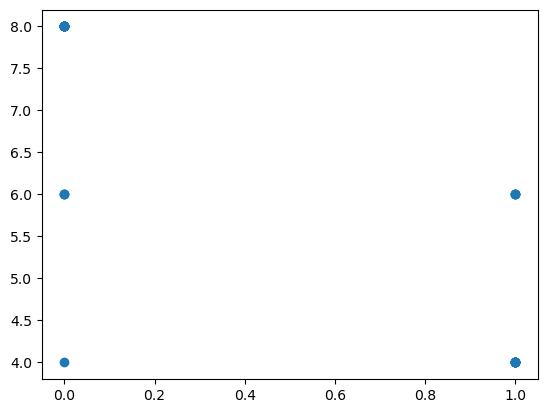

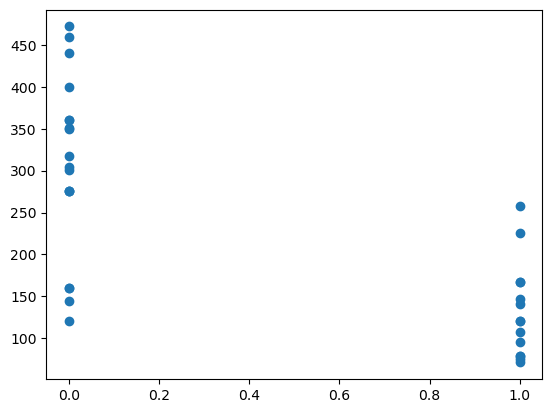

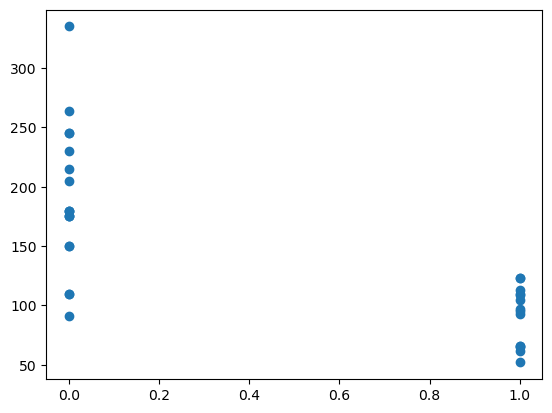

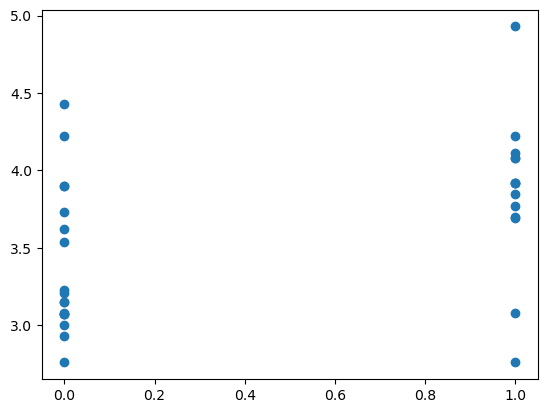

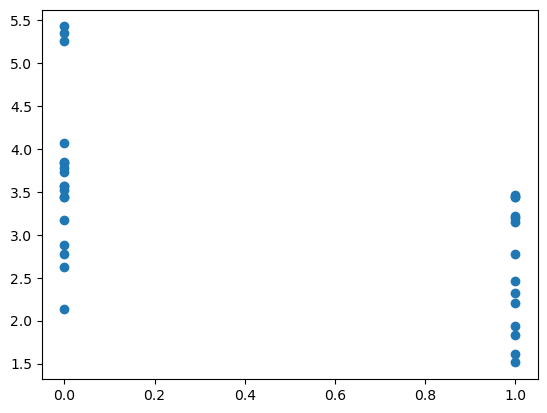

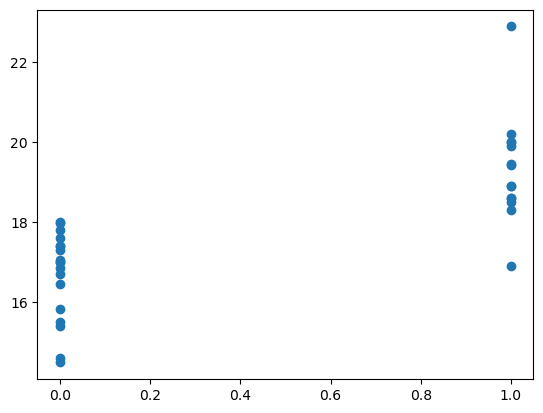

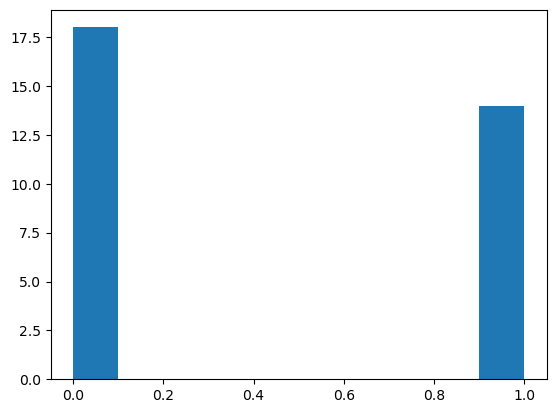

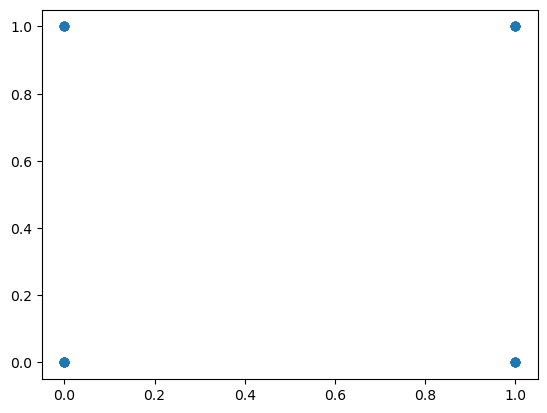

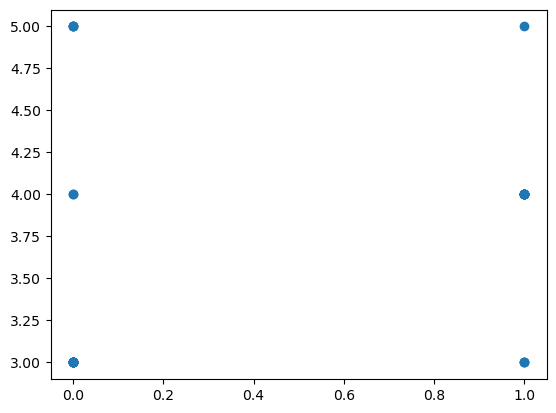

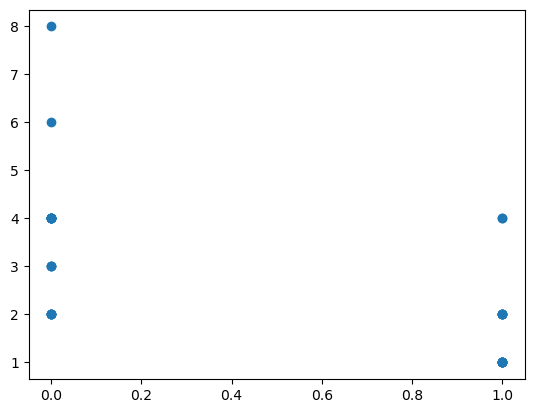

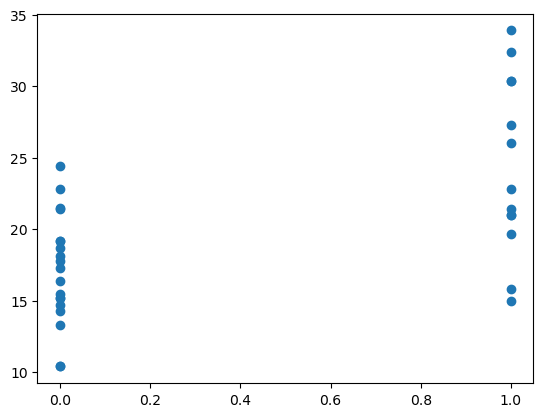

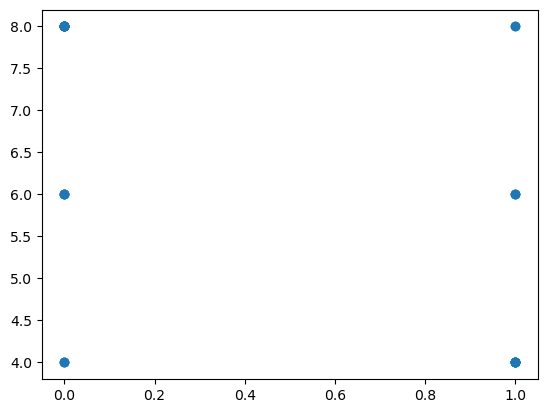

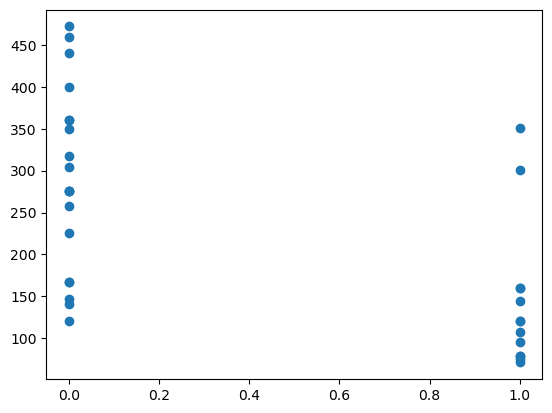

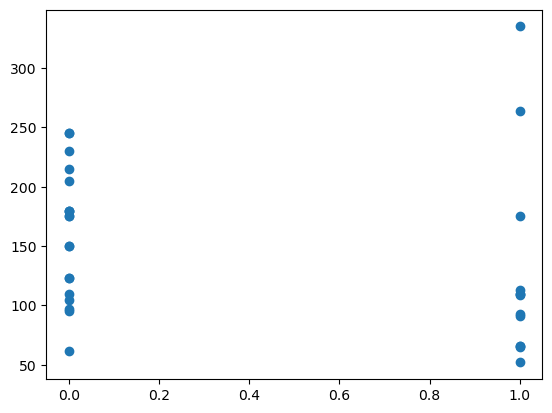

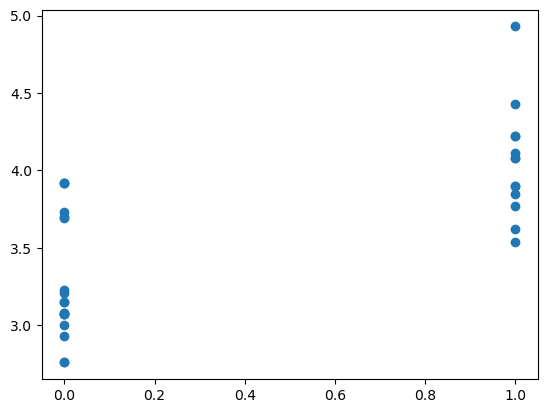

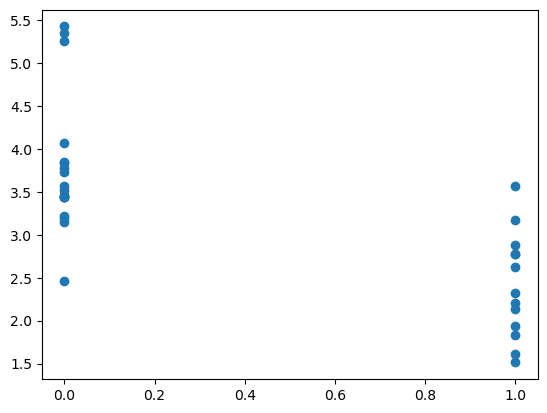

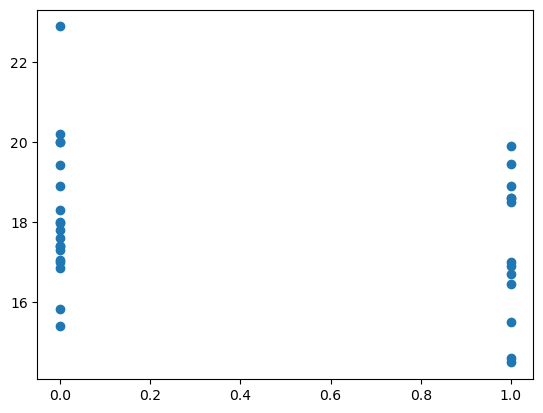

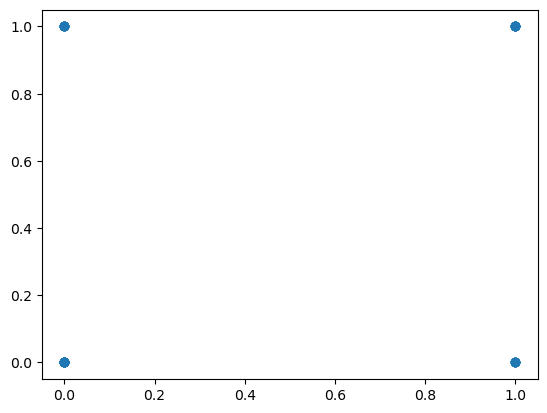

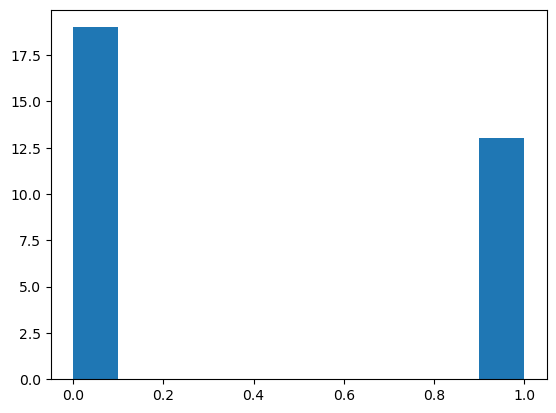

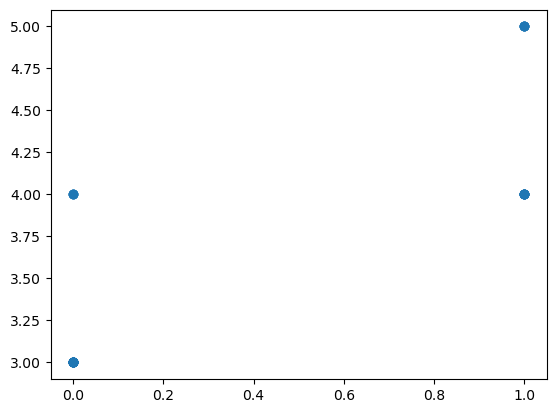

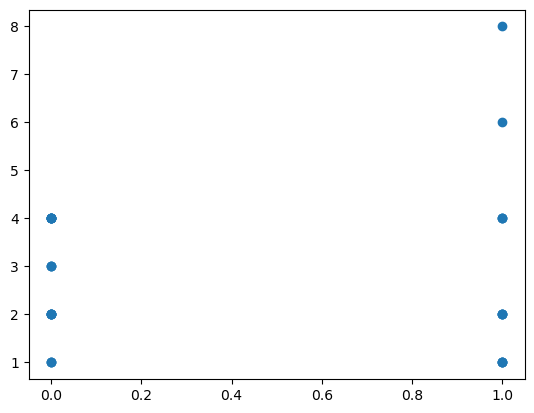

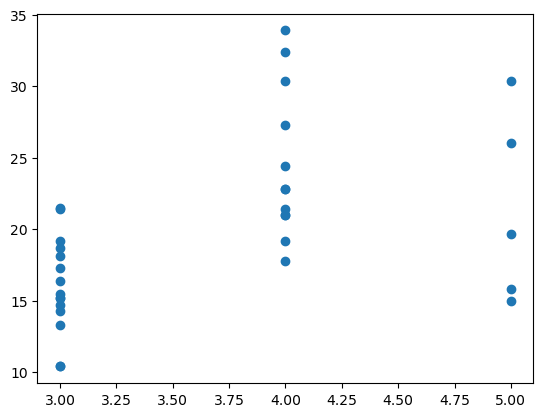

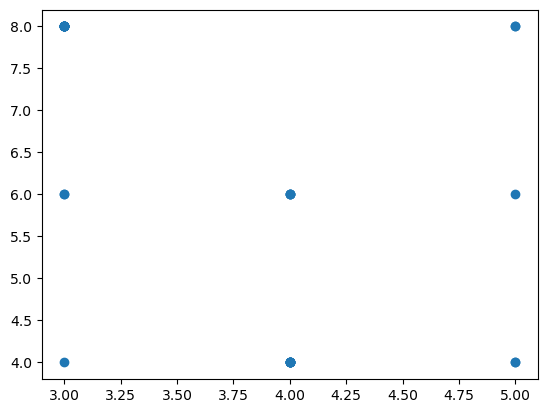

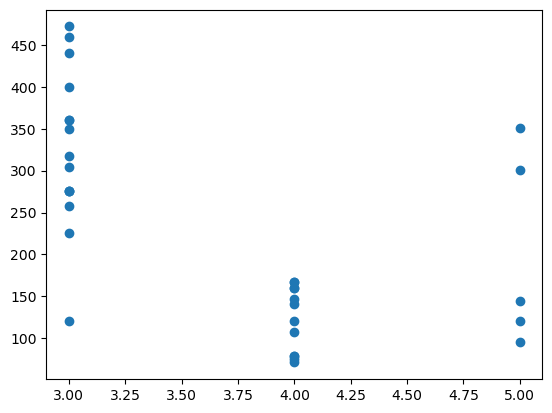

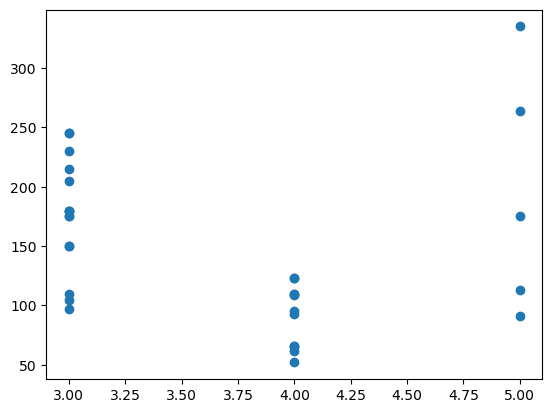

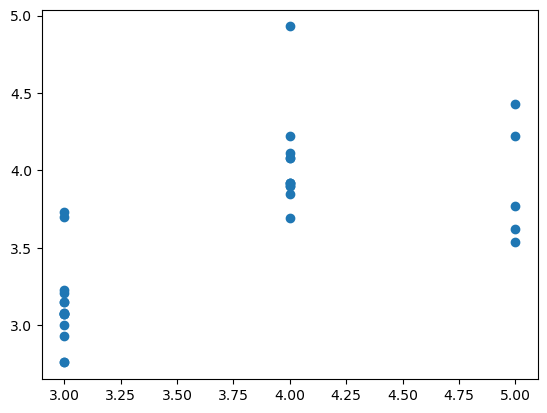

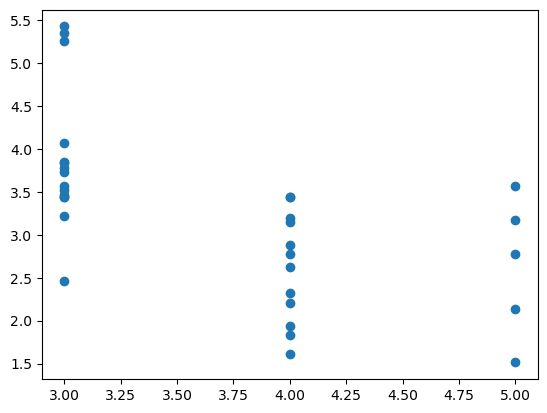

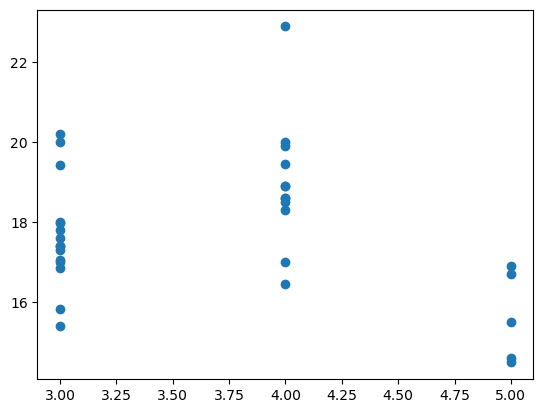

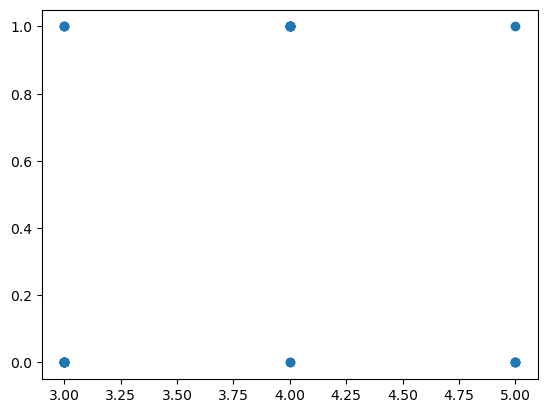

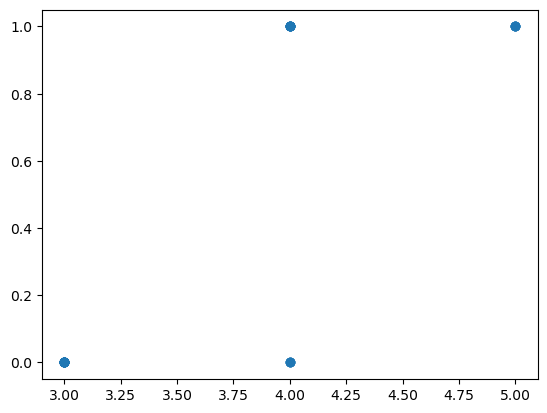

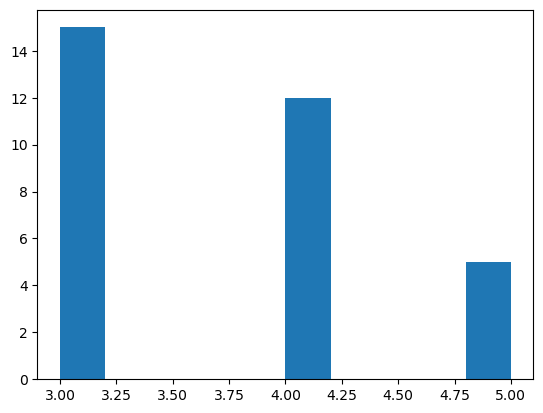

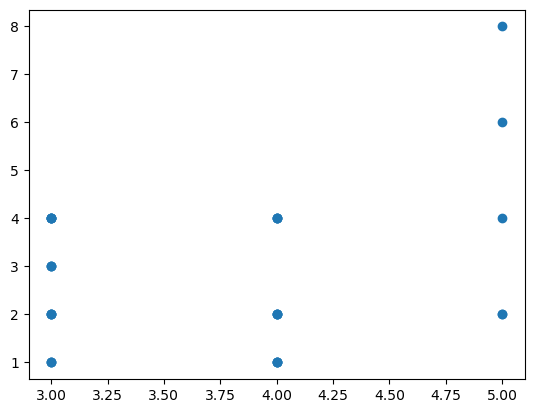

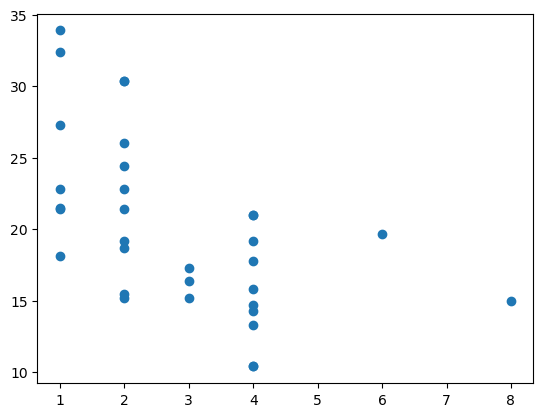

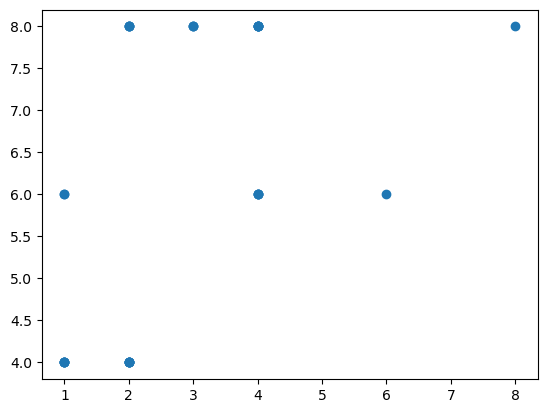

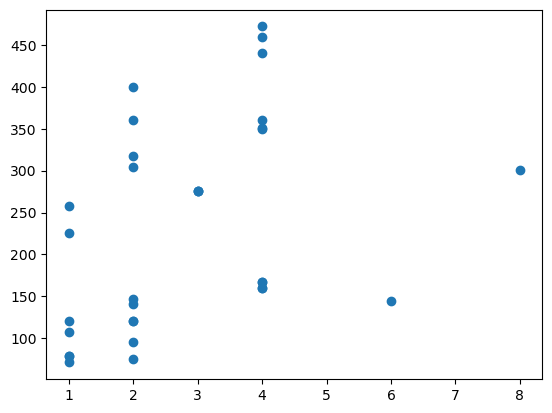

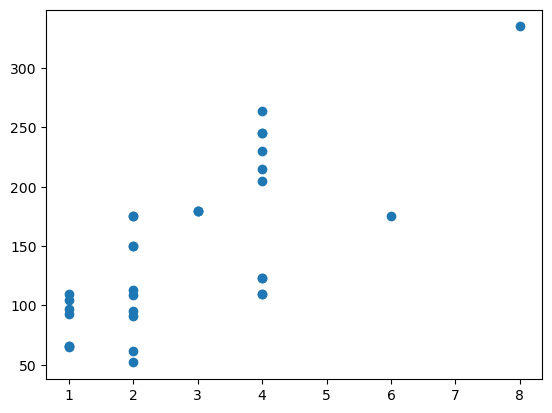

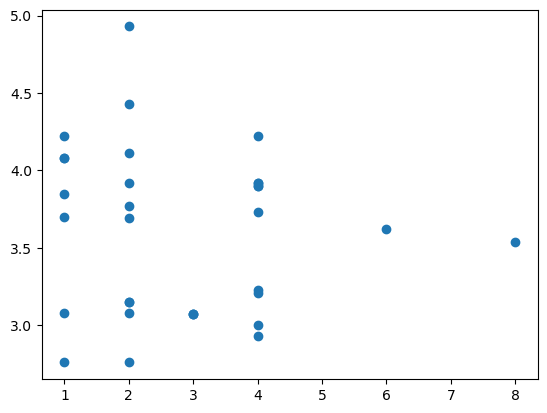

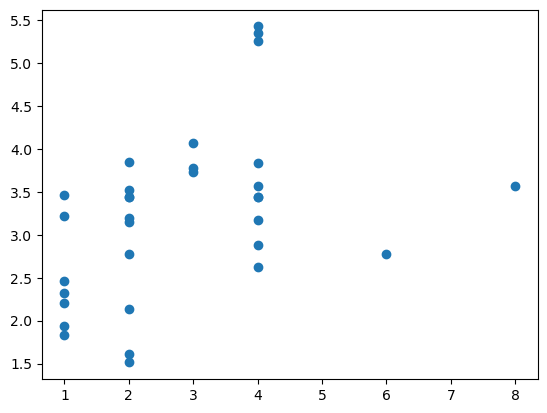

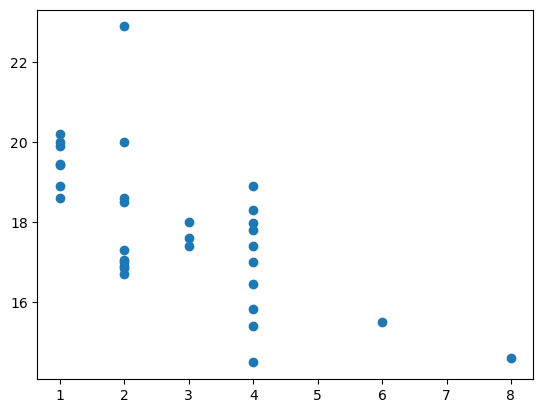

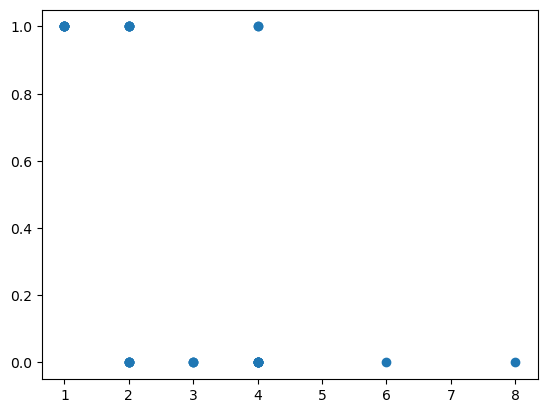

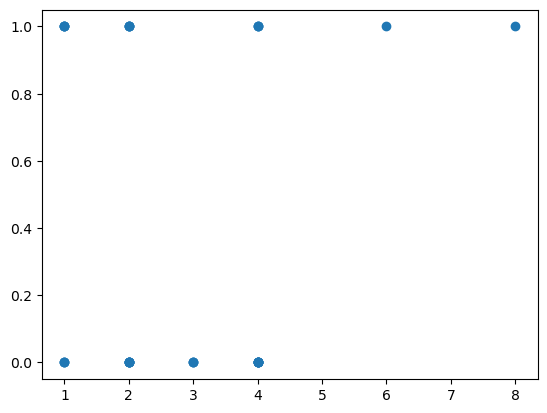

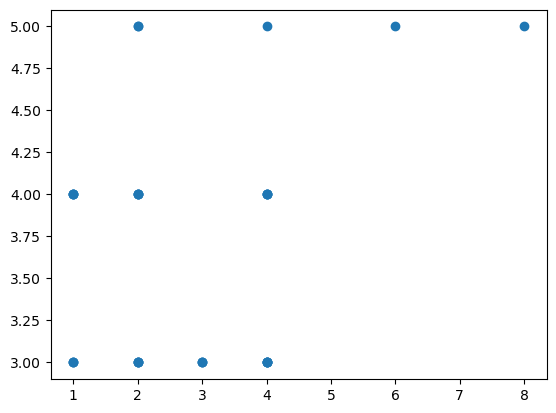

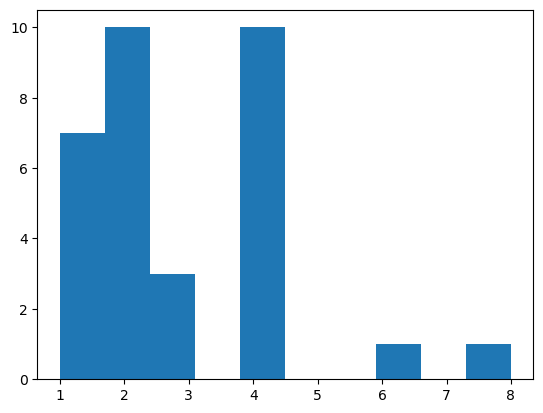

In [25]:
for i in range(len(df.columns)):
    for j in range(len(df.columns)):
        if(i != j):
            plt.scatter(df.iloc[:, i], df.iloc[:, j])
        else :
            plt.hist(df.iloc[:, i])
        plt.show()

### Dataset arbres

In [14]:
arbres = pd.read_csv("train.csv", index_col = 'ID_ARBRE')
X = arbres[["Lat", "Long"]].copy()
y = arbres[["classification_diagnostic"]]

# Prev : 
prev = pd.read_csv("prev.csv", index_col = 'ID_ARBRE')
prev = prev[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]].copy()
prev["esperance_maintien"] = prev["esperance_maintien"].astype(str)

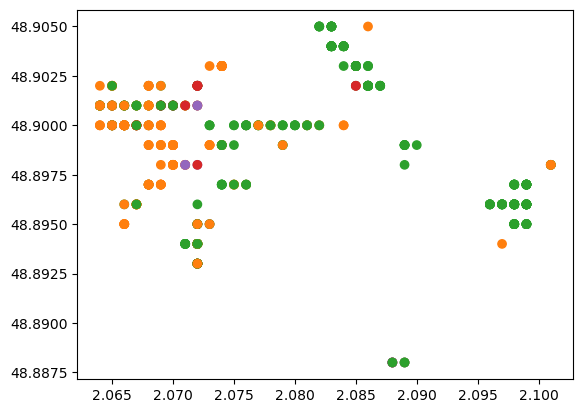

In [63]:
plt.scatter(X.iloc[:, 1], X.iloc[:, 0], c = y.iloc[:, 0])

## Decision Tree - Régression

In [348]:
class Node:

    def __init__(self, feature, value, left_node, right_node, depth, pop, cout, prediction=None):
        self.feature = feature # Un noeud contient une feature et une valeur pour split notre dataset
        self.value = value
        self.left_node = left_node # Il contient également une branche gauche...
        self.right_node = right_node #... et droite, appelée ici "node"
        self.depth = depth # Profondeur de l'arbre
        self.pop = pop # Taille de l'echantillon du noeud
        self.cout = cout # le cout de la séparation calculé avec l'indice Gini
        self.prediction = prediction #La classe majoritaire du noeud 


class decision_tree_regressor :

    def __init__(self, max_depth, seuil_mse, min_samples_split):
        self.max_depth = max_depth #La profondeur maximale
        self.seuil_mse = seuil_mse #Le seuil minimal de la MSE pour split notre dataset
        self.min_samples_split = min_samples_split

    def _split(self, feature, value, dataset):
        left = dataset[dataset[feature] <= value]
        right = dataset[dataset[feature] > value]
        return left, right

    def mse(self, y):
        arr = y.to_numpy()
        return np.mean((arr - np.mean(y))**2)
        

    def _best_split(self, X, y):
        best_feature, best_value, best_cost = X.columns[0], X.iloc[0, 0], np.inf
        
        for feature in X.columns:
            for value in X[feature].unique():
 
                idx_left = X[feature] <= value # On sépare en fonction d'une inégalité 
                y_left = y[idx_left]
                y_right = y[~idx_left]
                
                # On évite une division par zéro
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                cost = (len(y_left) * self.mse(y_left) + len(y_right) * self.mse(y_right))/len(y)
                
                if cost < best_cost:
                    # Si le couple (feature + valeur) possède le coût le plus faible, alors on le sauvegarde.
                    best_cost = cost
                    best_value = value
                    best_feature = feature
        return best_feature, best_value, best_cost

    def fit(self, X=None, y=None, depth=0):
        
        if len(y) <= 1:
            # on a 0 ou 1 échantillon : on crée une feuille
            prediction = np.mean(y) if len(y) > 0 else None
            return Node(feature=None,
                        value=None,
                        left_node=None,
                        right_node=None,
                        depth=depth,
                        pop=len(y),
                        cout=self.mse(y),
                        prediction=prediction
                       )
        
        # 1/ min_samples_split
        if self.min_samples_split is not None and len(y) < self.min_samples_split:
            prediction = np.mean(y) if len(y) > 0 else None
            node = Node(feature=None, value=None, left_node=None, right_node=None, depth=depth, pop=len(y), cout=self.mse(y), prediction=prediction)
            self.root = node
            return node

        
        # 2/ Max Depth
        if self.max_depth is not None and depth >= self.max_depth:
            prediction = np.mean(y) if len(y) > 0 else None
            node = Node(feature=None, value=None, left_node=None, right_node=None, depth=depth, pop=len(y), cout=self.mse(y), prediction=prediction)
            self.root = node
            return node
            
        # 3/ MSE seuil.
        if self.seuil_mse is not None and self.mse(y) <= self.seuil_mse:
            prediction = np.mean(y) if len(y) > 0 else None
            node = Node(feature=None, value=None, left_node=None, right_node=None, depth=depth, pop=len(y), cout=self.mse(y), prediction=prediction)
            self.root = node
            return node
            
        # Recherche du meilleur split
        best_feature, best_value, best_cost = self._best_split(X, y)
        prediction = np.mean(y) if len(y) > 0 else None
        
        """ if best_feature is None:
            node = Node(feature=None,
                        value=None,
                        left_node=None,
                        right_node=None,
                        depth=depth,
                        pop=len(y),
                        cout=self.mse(y),
                        prediction=prediction
                       )
            self.root = node
            return node """

        # On découpe selon l'index:
        idx_left = X[best_feature] <= best_value
        X_left, y_left = X[idx_left], y[idx_left] 
        X_right, y_right = X[~idx_left], y[~idx_left]

        left_node = self.fit(X_left, y_left, depth + 1)
        right_node = self.fit(X_right, y_right, depth + 1)        

        node = Node(
            feature=best_feature, 
            value=best_value, 
            left_node=left_node, 
            right_node=right_node, 
            depth=depth, 
            pop=len(y), 
            cout=best_cost, 
            prediction=None
        )
        self.root = node
        return node

    
    def predict_row(self, row, node=None):
        # predict() prend une ligne de dataset à la fois ("row") et la racine de l'arbre qu'on va parcourir pour prédire nos données.
        # Si notre noeud a pour paramètre feature = None, alors c'est qu'on fait face à un noeud terminal / feuille

        if node.feature is None:
            return node.prediction # Ici on retourne alors la classe majoritaire du noeud.
        if row[node.feature] <= node.value:
            return self.predict_row(row, node.left_node)
        else:
            return self.predict_row(row, node.right_node)

    def predict(self, X):
        # On prédit prédit les classes pour l'ensemble du DataFrame X. (Histoire de ne pas refaire de boucle sur chaque ligne du dataset à prédire)
        return X.apply(lambda row: self.predict_row(row, node=self.root), axis=1)

### Train_test_split

In [351]:
from sklearn.model_selection import train_test_split

In [353]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.30, random_state=42)

### Entraînement modèle - StratifiedKFold

In [364]:
tree = decision_tree_regressor(
    max_depth=None, 
    seuil_mse=None, 
    min_samples_split = None
)

In [366]:
root = tree.fit(X_train, Y_train) 

In [367]:
root.right_node

In [368]:
test_predict = tree.predict(X_test)
test_predict

rownames
Ferrari Dino           4.0
Lincoln Continental    4.0
Pontiac Firebird       4.0
Fiat 128               1.0
Merc 230               1.0
Merc 280               4.0
Maserati Bora          4.0
Fiat X1-9              4.0
Merc 450SL             3.0
Mazda RX4              4.0
dtype: float64

### Accuracy

In [667]:
def are(predict, Y):
    correct = np.sum(np.array(predict).flatten() == Y.to_numpy().flatten())
    taux = np.round((correct / len(Y)) * 100, 5)  # Pourcentage de bonnes prédictions
    return taux

In [668]:
are(test_predict, Y_test)

85.3211

### Recherches des paramètres
### 🛑Utilise tous les coeurs du processeur ✋

In [36]:
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed

In [38]:
depths_array = [5, 10, 15, 20]
gini_array = [0.10, 0.20, 0.30]
min_samples_split_array = [2, 5, 10]
min_impurity_decrease_array = [0.0, 0.01, 0.02]

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def best_params(depth, seuil, min_samples_split, min_impurity_decrease, folds, X, y):
    scores = []
    for train_index, test_index in folds.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]
        
        tree = decision_tree_classifier(max_depth=depth, 
                                        seuil=seuil, 
                                        min_samples_split=min_samples_split,
                                        min_impurity_decrease=min_impurity_decrease
                                       )
        root = tree.fit(X_train, Y_train)
        predictions = tree.predict(X_test, root=root)
        scores.append(are(predictions, Y_test))
    mean_score = np.mean(scores)
    return {
        "depth": depth,
        "seuil": seuil,
        "min_samples_split": min_samples_split,
        "min_impurity_decrease": min_impurity_decrease,
        "mean_score": mean_score
    }

In [113]:
# On distribue les tâches aux différents coeurs du processeurs pour accélérer la recherche des meilleurs paramètres.

resultats = Parallel(n_jobs=-1)(
    delayed(best_params)(depth, seuil, mss, mid, skf, X, y)
    for depth in depths_array
    for seuil in gini_array
    for mss in min_samples_split_array
    for mid in min_impurity_decrease_array
)

In [114]:
results_df = pd.DataFrame(resultats)
results_df.sort_values(by="mean_score", ascending=False)

,depth,seuil,min_samples_split,min_impurity_decrease,mean_score
87,20,0.1,10,0.00,83.269361
88,20,0.1,10,0.01,83.269360
61,15,0.1,10,0.01,83.269360
34,10,0.1,10,0.01,83.087541
60,15,0.1,10,0.00,83.084176
...,...,...,...,...,...
23,5,0.3,5,0.02,79.959597
18,5,0.3,2,0.00,79.959597
19,5,0.3,2,0.01,79.959597
20,5,0.3,2,0.02,79.959597


### Prédictions sur Prev

In [41]:
prev_predictions = tree.predict(prev, root=root)
prev_predictions

,classification_diagnostic
ID_ARBRE,
559,C2
560,C2
561,C2
562,C1
563,C3
...,...
694,C2
695,C3
696,C2


In [43]:
prev_predictions.value_counts()

classification_diagnostic
C2                           73
C1                           58
C3                            5
C5                            1
Name: count, dtype: int64

In [565]:
prev_predictions.to_csv("prev_dpth10_gni025.csv")

### Submition

In [541]:
sub = prev_predictions
sub.index.name = "ID_ARBRE"
id_arbre = prev_trie.index  # On récupère l'index chez x2
sub["ID_ARBRE"] = id_arbre  # Ajoute l'index comme colonne
sub = sub.set_index("ID_ARBRE")  # On définie 'ID_ARBRE' en tant qu'index

In [ ]:
sub.to_csv("sub_dpth10_gni025.csv")

## Random Forest

In [605]:
from itertools import combinations
all_combinations = list(combinations(range(13), 4))
random.shuffle(all_combinations)
all_combinations
selected_combinations = all_combinations[:100]
selected_combinations = [list(selected_combinations[i]) for i in range(len(selected_combinations))]
selected_combinations

[[5, 6, 8, 9],
 [0, 5, 8, 9],
 [1, 2, 4, 12],
 [0, 5, 7, 8],
 [2, 4, 6, 10],
 [1, 7, 10, 12],
 [0, 2, 8, 11],
 [3, 5, 8, 12],
 [2, 7, 9, 10],
 [0, 7, 9, 10],
 [0, 4, 6, 10],
 [0, 8, 11, 12],
 [1, 9, 11, 12],
 [3, 6, 9, 11],
 [1, 4, 9, 10],
 [2, 3, 9, 12],
 [2, 3, 10, 12],
 [4, 5, 11, 12],
 [1, 2, 3, 7],
 [3, 6, 9, 12],
 [2, 3, 4, 11],
 [2, 3, 5, 10],
 [1, 6, 7, 11],
 [0, 2, 6, 10],
 [1, 4, 7, 9],
 [2, 5, 7, 10],
 [2, 3, 10, 11],
 [2, 9, 10, 11],
 [1, 2, 4, 11],
 [6, 7, 9, 12],
 [2, 9, 11, 12],
 [0, 2, 7, 10],
 [1, 2, 5, 12],
 [2, 6, 9, 12],
 [0, 6, 9, 11],
 [0, 6, 8, 9],
 [1, 3, 11, 12],
 [3, 4, 9, 12],
 [7, 8, 9, 10],
 [4, 6, 7, 12],
 [1, 5, 6, 9],
 [3, 5, 9, 12],
 [2, 5, 8, 10],
 [0, 2, 8, 10],
 [2, 3, 5, 6],
 [2, 5, 9, 12],
 [6, 7, 8, 11],
 [6, 8, 10, 11],
 [6, 9, 10, 11],
 [0, 2, 6, 11],
 [0, 7, 8, 10],
 [2, 3, 11, 12],
 [1, 5, 8, 12],
 [0, 5, 11, 12],
 [3, 4, 9, 10],
 [2, 5, 7, 12],
 [1, 2, 6, 11],
 [0, 1, 2, 11],
 [0, 5, 6, 7],
 [2, 8, 11, 12],
 [1, 7, 11, 12],
 [2, 5, 9, 11],
 [

In [673]:
random.seed(1)

class RandomForest:

    def __init__(self, nb_trees, nb_features_per_tree, max_depth, min_sample_split, seuil):
        self.nb_trees = nb_trees
        self.nb_features_per_tree = nb_features_per_tree
        self.max_depth = max_depth
        self.min_sample_split = min_sample_split
        self.seuil = seuil
        self.all_trees = []  # pour stocker les arbres

    def combinaisons(self, X):
        #                                         13 colonnes          4 features per tree    ==> (4 parmis 13)
        all_combinations = list(combinations(range(len(X.columns)), self.nb_features_per_tree))
        random.shuffle(all_combinations)
        selected_combinations = all_combinations[:self.nb_trees]
        selected_combinations = [list(selected_combinations[i]) for i in range(len(selected_combinations))]
        return selected_combinations

    def forest_fit(self, X=None, y=None):
        features_idxs = self.combinaisons(X)
        
        for i in range(self.nb_trees):
            tree = decision_tree_classifier(
                max_depth=self.max_depth, 
                seuil=self.seuil, 
                min_samples_split= self.min_sample_split, 
                min_impurity_decrease = None
            )
            indices = np.random.choice(len(X), len(X), replace=True)
            X_bootstrap = X.iloc[indices, features_idxs[i]]
            y_bootstrap = y.iloc[indices]
            root = tree.fit(X_bootstrap, y_bootstrap)
            self.all_trees.append([features_idxs[i], tree, root])

    def forest_predict(self, X_predict):
        predictions = []
        for idxs, tree, root in self.all_trees:
            X_subset = X_predict.iloc[:, idxs]
            p = tree.predict(X_subset, root).iloc[:,0].to_list()
            predictions.append(p)
        predictions = pd.DataFrame(predictions).T
        return predictions.mode(axis=1)[0]  # une Series contenant la classe majoritaire
        

In [675]:
forest = RandomForest(nb_trees=10, nb_features_per_tree=5, max_depth=15, min_sample_split=10, seuil=0.05)

In [677]:
forest.forest_fit(X_train, Y_train)

In [678]:
forest_test_predict = forest.forest_predict(X_test)
forest_test_predict

0      C2
1      C1
2      C1
3      C1
4      C2
       ..
104    C2
105    C2
106    C2
107    C2
108    C2
Name: 0, Length: 109, dtype: object

In [679]:
are(forest_test_predict, Y_test)

78.89908

### Params Finding

In [490]:
from sklearn.model_selection import StratifiedKFold, KFold 
from joblib import Parallel, delayed

In [492]:
def best_params(nb_trees, nb_features_per_tree, max_depth, min_sample_split, seuil, folds, X, y):
    scores = []
    for train_index, test_index in folds.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]
        
        forest = RandomForest(
            nb_trees = nb_trees, 
            nb_features_per_tree = nb_features_per_tree, 
            max_depth = max_depth, 
            min_sample_split = min_sample_split, 
            seuil = seuil
        )
        forest.forest_fit(X_train, Y_train)
        forest_test_predict = forest.forest_predict(X_test)
        scores.append(are(forest_test_predict, Y_test))
    mean_score = np.mean(scores)
    return {
        "nb_trees" : nb_trees,
        "nb_features_per_tree" : nb_features_per_tree,
        "max_depth": max_depth,
        "min_sample_split" : min_sample_split,
        "seuil": seuil,
        "mean_score": mean_score
    }

In [631]:
nb_trees_array = [30]
nb_features_per_tree = [5]
gini_array = [0.05, 0.10]
min_samples_split_array = [10, 15]
depths_array = [10, 15, 20, 25, 30]

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# On distribue les tâches aux différents coeurs du processeurs pour accélérer la recherche des meilleurs paramètres.
resultats = Parallel(n_jobs=-1)(
    delayed(best_params)(trsa, fts, depth, mss, seuil, kf, X, y)
    for trsa in nb_trees_array
    for fts in nb_features_per_tree
    for depth in depths_array
    for mss in min_samples_split_array
    for seuil in gini_array
)

In [633]:
results_df = pd.DataFrame(resultats)
results_df.sort_values(by="mean_score", ascending=False).head(20)

,nb_trees,nb_features_per_tree,max_depth,min_sample_split,seuil,mean_score
66,30,5,15,10,0.05,83.088457
83,30,5,20,10,0.10,82.904297
99,30,5,25,10,0.10,82.536983
179,40,5,30,10,0.10,82.354847
49,20,5,30,10,0.01,82.174733
70,30,5,15,20,0.05,81.989557
97,30,5,25,10,0.01,81.988547
162,40,5,25,10,0.05,81.984497
82,30,5,20,10,0.05,81.803373
2,20,5,15,10,0.05,81.801347


In [659]:
prev_predict = pd.DataFrame(forest.forest_predict(prev))
index = prev.index
prev_predict = prev_predict.set_index(index)
prev_predict.columns = ["classification_diagnostic"]
prev_predict.to_csv("random_forest.csv")

## SKLearn

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.1, random_state=42)

### Decision Tree Regressor

In [14]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

In [15]:
regressor = DecisionTreeRegressor()

In [149]:
regressor.fit(X_train, Y_train)

DecisionTreeRegressor()

In [151]:
regressor.score(X_test, Y_test)

0.6610169491525424